In [2]:
import os

In [3]:
import pandas as pd

df = pd.read_csv("./reduced_chord_codebook.csv")
df

original_alphabet = df['original_code'].unique().tolist()
reduced_alphabet = df['reduced_code'].unique().tolist()

original_alphabet_str = " ".join([str(s) for s in original_alphabet])
reduced_alphabet_str = " ".join([str(s) for s in reduced_alphabet])
print(f"original alphabet = [{original_alphabet_str}]")
print(f"reduced alphabet = [{reduced_alphabet_str}]")

original alphabet = [1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272

In [29]:
"""
Rewrite IDYOM chord sequence files replacing original chord codes with reduced codes.

For each batch folder under `batched_folder_before_reduction`, reads
new-training-data.txt and new-test-data.txt, replaces every chord code
with its reduced equivalent (via the reduction map from the CSV), and
writes the results to the corresponding folder under `batched_folder`.

Special rule: the LAST ROW of every test file is treated as the full alphabet
listing. It is always replaced wholesale with `reduced_alphabet_str`
(the sorted, deduplicated reduced codes in ordinal order), regardless of
what integers appear there.
"""

import os
import pandas as pd


# ---------------------------------------------------------------------------
# 1. Load the reduction map
# ---------------------------------------------------------------------------

def load_reduction_map(csv_path: str) -> dict[int, int]:
    """
    Load the chord reduction CSV and return a dict:
        original_code (int) → reduced_code (int)

    Parameters
    ----------
    csv_path : str
        Path to the CSV produced by reduce_chord_alphabet.py.
        Expected columns: original_code, original_label, reduced_label, reduced_code.

    Returns
    -------
    dict[int, int]
    """
    df = pd.read_csv(csv_path)
    return dict(zip(df["original_code"].astype(int),
                    df["reduced_code"].astype(int)))


# ---------------------------------------------------------------------------
# 2. Map a single row of space-separated codes
# ---------------------------------------------------------------------------

def map_row(row: str, reduction_map: dict[int, int]) -> str:
    """
    Replace every space-separated integer in `row` with its reduced code.

    Unknown codes are passed through unchanged with a warning, so the file
    is never silently truncated.

    Parameters
    ----------
    row : str
        A single line from the data file, e.g. "1 3 1 155 6 1 3 1 2 1 160"
    reduction_map : dict[int, int]
        Maps original_code → reduced_code.

    Returns
    -------
    str
        The mapped row as a space-separated string.
    """
    tokens = row.strip().split()
    mapped = []
    for tok in tokens:
        try:
            orig = int(tok)
            reduced = reduction_map.get(orig)
            if reduced is None:
                # Pass unknown codes through and warn; don't silently drop them.
                print(f"  [WARNING] Unknown chord code {orig!r} — keeping as-is")
                mapped.append(tok)
            else:
                mapped.append(str(reduced))
        except ValueError:
            # Non-integer token (shouldn't happen in well-formed files)
            print(f"  [WARNING] Non-integer token {tok!r} — keeping as-is")
            mapped.append(tok)
    return " ".join(mapped)
    
# ---------------------------------------------------------------------------
# 3. Rewrite a single file
# ---------------------------------------------------------------------------

def rewrite_file(src_path: str,
                 dst_path: str,
                 reduction_map: dict[int, int],
                 reduced_alphabet_str: str) -> None:
    """
    Read a chord sequence file, map all codes to their reduced equivalents,
    replace the last row with the full reduced alphabet, and write the result.

    Parameters
    ----------
    src_path : str
        Full path to the source file.
    dst_path : str
        Full path to the destination file.
    reduction_map : dict[int, int]
        Maps original_code → reduced_code.
    reduced_alphabet_str : str
        Space-separated string of all reduced codes (the canonical alphabet row).
    """
    with open(src_path, "r", encoding="utf-8") as fh:
        # Strip trailing blank lines so the "last row" logic is reliable.
        lines = [ln.rstrip("\n") for ln in fh]

    # Drop trailing empty lines for the purpose of identifying the last row,
    # but we'll re-add a final newline when writing.
    non_empty = [(i, ln) for i, ln in enumerate(lines) if ln.strip()]
    if not non_empty:
        # Edge case: entirely empty file — write it as-is
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        with open(dst_path, "w", encoding="utf-8") as fh:
            fh.write("\n".join(lines))
        return

    last_non_empty_idx = non_empty[-1][0]

    mapped_lines = []
    for i, line in enumerate(lines):
        if not line.strip():
            # Preserve blank lines exactly
            mapped_lines.append(line)
        elif i == last_non_empty_idx:
            # Last data row → always replace with full reduced alphabet
            mapped_lines.append(reduced_alphabet_str)
        else:
            mapped_lines.append(map_row(line, reduction_map))

    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with open(dst_path, "w", encoding="utf-8") as fh:
        fh.write("\n".join(mapped_lines))
        # Preserve a trailing newline if the original had one
        if lines and lines[-1] == "":
            fh.write("\n")


# ---------------------------------------------------------------------------
# 4. Main rewriting pipeline
# ---------------------------------------------------------------------------

def rewrite_all_batches(batched_folder_before_reduction: str,
                        batched_folder: str,
                        reduction_map: dict[int, int],
                        reduced_alphabet_str: str,
                        filenames: list[str] | None = None) -> None:
    """
    Walk every batch sub-folder in `batched_folder_before_reduction`, rewrite
    the relevant data files into `batched_folder`, preserving the directory
    structure. All other files (e.g. lisp-cmd-*.lisp) are copied unchanged.

    Parameters
    ----------
    batched_folder_before_reduction : str
        Root folder containing batch sub-directories (e.g. "idyom-reanalysis").
    batched_folder : str
        Root folder for output (e.g. "idyom-reanalysis_reduced-alphabet").
    reduction_map : dict[int, int]
        Maps original_code → reduced_code.
    reduced_alphabet_str : str
        The canonical reduced-alphabet row used to replace the last line.
    filenames : list[str] or None
        Which filenames to rewrite. Defaults to
        ["new-training-data.txt", "new-test-data.txt"].
        All other files in the batch folders are copied as-is.
    """
    import shutil

    if filenames is None:
        filenames = ["new-training-data.txt", "new-test-data.txt"]

    filenames_set = set(filenames)

    # Discover batch folders (immediate sub-directories, ignoring hidden ones)
    batches = sorted(
        d.name for d in os.scandir(batched_folder_before_reduction)
        if d.is_dir() and not d.name.startswith(".")
    )

    if not batches:
        print(f"[WARNING] No batch sub-folders found in {batched_folder_before_reduction!r}")
        return

    print(f"Found {len(batches)} batch(es): {batches}")

    for batch in batches:
        src_batch_dir = os.path.join(batched_folder_before_reduction, batch)
        dst_batch_dir = os.path.join(batched_folder, batch)
        os.makedirs(dst_batch_dir, exist_ok=True)

        for entry in os.scandir(src_batch_dir):
            if not entry.is_file():
                continue
            src_path = entry.path
            dst_path = os.path.join(dst_batch_dir, entry.name)

            if entry.name in filenames_set:
                # Rewrite: map chord codes → reduced codes
                print(f"  Rewriting {batch}/{entry.name} …")
                rewrite_file(src_path, dst_path, reduction_map, reduced_alphabet_str)
            else:
                # Copy all other files unchanged (e.g. lisp-cmd-*.lisp)
                shutil.copy2(src_path, dst_path)
                print(f"  Copied   {batch}/{entry.name}")

    print("\nDone. Reduced files written to:", batched_folder)


# ---------------------------------------------------------------------------
# 5. Notebook-ready entry point
# ---------------------------------------------------------------------------

# --- Paths (edit as needed) ---
CSV_PATH                      = "./reduced_chord_codebook.csv"
BATCHED_FOLDER_BEFORE         = "./idyom-reanalysis"
BATCHED_FOLDER_AFTER          = "./idyom-reanalysis_reduced-alphabet"
TRAIN_FILENAME                = "new-training-data.txt"
TEST_FILENAME                 = "new-test-data.txt"

# --- Build the reduction map ---
reduction_map = load_reduction_map(CSV_PATH)

# --- Build the reduced alphabet string ---
df = pd.read_csv(CSV_PATH)
# Ordinal reduced codes 1..N in ascending order — these are already ordinal
# so sorting numerically gives the canonical alphabet row.
reduced_codes = sorted(df["reduced_code"].unique().tolist())
reduced_alphabet_str = " ".join(str(c) for c in reduced_codes)

print(f"Reduction map loaded: {len(reduction_map)} original codes → "
      f"{len(reduced_codes)} reduced codes")
print(f"Reduced alphabet: {reduced_alphabet_str[:80]}…")

# --- Rewrite all batch folders ---
rewrite_all_batches(
    batched_folder_before_reduction=BATCHED_FOLDER_BEFORE,
    batched_folder=BATCHED_FOLDER_AFTER,
    reduction_map=reduction_map,
    reduced_alphabet_str=reduced_alphabet_str,
    filenames=[TRAIN_FILENAME, TEST_FILENAME],
)

# --- Rewrite stimuli_batch_mapping.csv ---
df_stimuli = pd.read_csv("./stimuli_batch_mapping.csv")
df_stimuli["seq_str_reduced"] = df_stimuli["seq_str"].astype(str).apply(
    lambda row: map_row(row, reduction_map)
)
df_stimuli.to_csv("stimuli_batch_mapping.csv", index=False)

Reduction map loaded: 692 original codes → 137 reduced codes
Reduced alphabet: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30…
Found 8 batch(es): ['1', '2', '3', '4', '5', '6', '7', '8']
  Copied   1/lisp-cmd-1.lisp
  Rewriting 1/new-test-data.txt …
  Rewriting 1/new-training-data.txt …
  Copied   2/lisp-cmd-1.lisp
  Rewriting 2/new-test-data.txt …
  Rewriting 2/new-training-data.txt …
  Copied   3/lisp-cmd-1.lisp
  Rewriting 3/new-test-data.txt …
  Rewriting 3/new-training-data.txt …
  Copied   4/lisp-cmd-1.lisp
  Rewriting 4/new-test-data.txt …
  Rewriting 4/new-training-data.txt …
  Copied   5/lisp-cmd-1.lisp
  Rewriting 5/new-test-data.txt …
  Rewriting 5/new-training-data.txt …
  Copied   6/lisp-cmd-1.lisp
  Rewriting 6/new-test-data.txt …
  Rewriting 6/new-training-data.txt …
  Copied   7/lisp-cmd-1.lisp
  Rewriting 7/new-test-data.txt …
  Rewriting 7/new-training-data.txt …
  Copied   8/lisp-cmd-1.lisp
  Rewriting 8/new-test-data.txt …
  Rewriti

In [18]:
df = pd.read_csv("reduced_chord_codebook.csv")

REDUCED_CODE_TO_LABEL = dict(
    zip(df["reduced_code"].astype(int), df["reduced_label"])
)
ORIGINAL_CODE_TO_LABEL = dict(
    zip(df["original_code"].astype(int), df["original_label"])
)

# Chromatic note names (two options per accidental — choose by preference)
CHROMATIC_SHARPS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
CHROMATIC_FLATS  = ["C", "Db", "D", "Eb", "E", "F", "Gb", "G", "Ab", "A", "Bb", "B"]

# Which spelling to prefer for each tonic (conventional music theory choices)
TONIC_USES_FLATS = {1, 3, 5, 8, 10}  # Db, Eb, F, Ab, Bb tonics → flat spellings

def pc_to_note(pc: int, tonic_pc: int = 0) -> str:
    names = CHROMATIC_FLATS if tonic_pc in TONIC_USES_FLATS else CHROMATIC_SHARPS
    return names[pc % 12]


def reduced_label_to_symbol(label: str, tonic_pc: int = 0) -> str:
    if ":" not in label:
        return label
    pc_str, quality = label.split(":", 1)
    try:
        pc = int(pc_str)
        note = pc_to_note(pc, tonic_pc)
    except ValueError:
        note = pc_str
    return f"{note}:{quality}"


def map_code_row_to_symbol(row: str, tonic_pc: int = 0, code_to_label: dict = None) -> str:
    """
    Replace every space-separated integer code in `row` with its chord symbol.

    Parameters
    ----------
    row : str
        Space-separated integer codes, e.g. "1 5 1 2 7 1".
    tonic_pc : int
        Pitch class of the tonic (0 = C, 9 = A, etc.). Default 0.
    code_to_label : dict, optional
        Maps code → label. Defaults to REDUCED_CODE_TO_LABEL.
        Pass ORIGINAL_CODE_TO_LABEL to decode original-alphabet sequences.
    """
    lookup = code_to_label if code_to_label is not None else REDUCED_CODE_TO_LABEL
    tokens = row.strip().split()
    mapped = []
    for tok in tokens:
        try:
            code = int(tok)
            label = lookup.get(code)
            if label is None:
                print(f"  [WARNING] Unknown code {code!r} — keeping as-is")
                mapped.append(tok)
            else:
                mapped.append(reduced_label_to_symbol(label, tonic_pc))
        except ValueError:
            print(f"  [WARNING] Non-integer token {tok!r} — keeping as-is")
            mapped.append(tok)
    return " ".join(mapped)


## Systematically swap all eligible chords with all alternate chords

For each of the 360 sequences meeting Cheung's criteria (located in `entropy_surprisal_fmri/output/stimuli/May-25/using-stim-corr-and-picking-best-sequences/idyom-reanalysis/`), chords at positions 5 through -5 are systematically replaced one at a time with each alternative chord in the alphabet, generating a set of minimally modified sequences for analysis.
The original idyom-reanalysis data is divided into 8 batches, each containing at least 50 of the 360 eligible test sequences. For each batch, the model is trained on all corpus songs excluding those from which the batch's 50 test sequences were drawn, and evaluated on those 50 sequences.

In [12]:
batched_folder_before_reduction = "./idyom-reanalysis"
batched_folder = "./idyom-reanalysis_reduced-alphabet"

batches = [d.name for d in os.scandir("idyom-reanalysis") if d.is_dir() and not d.name.startswith(".")]
print(f"Found batches: {batches}")

train_filename = "new-training-data.txt"
test_filename = "new-test-data.txt"

IDYOM_SWAP_INPUT_FOLDER = "./idyom-swap-inputs"
os.makedirs(IDYOM_SWAP_INPUT_FOLDER, exist_ok=True)

TARGET_CHORD_MIN_OFFSET = 5
SUB_BATCH_SIZE = 70

Found batches: ['7', '6', '1', '8', '4', '3', '2', '5']


In [32]:
15//2

7

### Centered position

In [35]:
# for batch in batches:
#     idyom_swap_input_batch_folder = os.path.join(IDYOM_SWAP_INPUT_FOLDER, f"batch_{batch}")
#     os.makedirs(idyom_swap_input_batch_folder, exist_ok=True)
#     with open(os.path.join(batched_folder, batch, test_filename), "r") as f:
#         lines = f.readlines()
#     print(f"Iterating over sequences in batch {batch}...")
#     for seq_i in range(0, len(lines)-1):
#         seq = lines[seq_i]


# For now, only use the final stimuli in Cheung's study to run the swap experiment.
import pandas as pd

# Load the mapping CSV
seq_batch_mapping = pd.read_csv("stimuli_batch_mapping.csv")
for batch in batches:
    idyom_swap_input_batch_folder = os.path.join(IDYOM_SWAP_INPUT_FOLDER, f"batch_{batch}")
    os.makedirs(idyom_swap_input_batch_folder, exist_ok=True)
    with open(os.path.join(batched_folder, batch, test_filename), "r") as f:
        lines = f.readlines()

    print(f"Iterating over sequences in batch {batch}...")
    for seq_i in range(0, len(lines)-1): # ignore the last line - full alphabet
        seq_str = lines[seq_i]
        seq = f"{seq_str.strip()}"
    
    # stimuli_seqs = seq_batch_mapping[
    #     seq_batch_mapping["belonged_batch"].astype(str).str.split(",").apply(lambda x: str(batch) in x)
    # ]["seq_str_reduced"].tolist()
    
    # print(f"Iterating over sequences in batch {batch}... ({len(stimuli_seqs)} sequences)")
    
    # for seq_str in stimuli_seqs:
    #     # Add a dummy ending for entropy calculation of the last valid chord
    #     seq = f"{seq_str.strip()} 1"
        
    #     seq_i = next((i for i, line in enumerate(lines) if seq == line.strip()), None)
    #     if seq_i is None:
    #         print(f"  WARNING: seq not found in {test_filename} for batch {batch}: {seq}...")
    #         continue
            
        idyom_swap_input_batch_seq_folder = os.path.join(idyom_swap_input_batch_folder, f"seq_{seq_i}")
        os.makedirs(idyom_swap_input_batch_seq_folder, exist_ok=True)
        
        chords = seq.split(" ")
        
        # For now, only swap the middle chord
        chord_i = len(chords) // 2
        
        # sequence length ranges from 30 to 38, so we are safe from index out of bound error.
        # for chord_i in range(TARGET_CHORD_MIN_OFFSET, len(chords) - TARGET_CHORD_MIN_OFFSET):
        
        chord = chords[chord_i]

        modified_seqs = []
        for symbol in reduced_alphabet:
            modified_chords = chords.copy()
            modified_chords[chord_i] = str(symbol)
            modified_seqs.append(" ".join(modified_chords))

        sub_batches = [modified_seqs[i:i+SUB_BATCH_SIZE] for i in range(0, len(modified_seqs), SUB_BATCH_SIZE)]
        for sub_batch_i, sub_batch_seqs in enumerate(sub_batches):
            filepath = os.path.join(
                idyom_swap_input_batch_seq_folder,
                f"chord_{chord_i}_sym_{chord}_batch_{sub_batch_i}.txt"
            )
            with open(filepath, "w") as f:
                for seq in sub_batch_seqs:
                    f.write(f"{seq}\n")
                # The last element of is a sequence of the alphabet, which is included so as to ensure that the analysis uses the whole alphabet available in  the corpus.
                f.write(reduced_alphabet_str + "\n")

Iterating over sequences in batch 7...
Iterating over sequences in batch 6...
Iterating over sequences in batch 1...
Iterating over sequences in batch 8...
Iterating over sequences in batch 4...
Iterating over sequences in batch 3...
Iterating over sequences in batch 2...
Iterating over sequences in batch 5...


### Non-middle positions

In [56]:
os.makedirs(IDYOM_SWAP_INPUT_FOLDER, exist_ok=True)

for batch in batches:
    idyom_swap_input_batch_folder = os.path.join(IDYOM_SWAP_INPUT_FOLDER, f"batch_{batch}")
    os.makedirs(idyom_swap_input_batch_folder, exist_ok=True)

    with open(os.path.join(batched_folder, batch, test_filename), "r") as f:
        lines = f.readlines()

    print(f"Iterating over sequences in batch {batch}...")
    for seq_i in range(0, len(lines) - 1):  # ignore last line (full alphabet)
        seq = lines[seq_i].strip()
        chords = seq.split(" ")
        middle_chord_i = len(chords) // 2

        target_chord_indices = [
            i for i in range(TARGET_CHORD_MIN_OFFSET, len(chords) - TARGET_CHORD_MIN_OFFSET)
            if i != middle_chord_i
        ]

        idyom_swap_input_batch_seq_folder = os.path.join(
            idyom_swap_input_batch_folder, f"seq_{seq_i}"
        )
        os.makedirs(idyom_swap_input_batch_seq_folder, exist_ok=True)

        for chord_i in target_chord_indices:
            chord = chords[chord_i]

            modified_seqs = []
            for symbol in reduced_alphabet:
                modified_chords = chords.copy()
                modified_chords[chord_i] = str(symbol)
                modified_seqs.append(" ".join(modified_chords))

            sub_batches = [
                modified_seqs[i:i + SUB_BATCH_SIZE]
                for i in range(0, len(modified_seqs), SUB_BATCH_SIZE)
            ]
            for sub_batch_i, sub_batch_seqs in enumerate(sub_batches):
                filepath = os.path.join(
                    idyom_swap_input_batch_seq_folder,
                    f"chord_{chord_i}_sym_{chord}_batch_{sub_batch_i}.txt"
                )
                with open(filepath, "w") as f:
                    for s in sub_batch_seqs:
                        f.write(f"{s}\n")
                    f.write(reduced_alphabet_str + "\n")

print("Done writing swap inputs.")

Iterating over sequences in batch 7...
Iterating over sequences in batch 6...
Iterating over sequences in batch 1...
Iterating over sequences in batch 8...
Iterating over sequences in batch 4...
Iterating over sequences in batch 3...
Iterating over sequences in batch 2...
Iterating over sequences in batch 5...
Done writing swap inputs.


## Batch run IDyOM

In [59]:
LISP_COMMAND = """
(start-idyom)
(idyom-db:import-data :txt %s "TRAIN_DATASET" %s)
(idyom-db:import-data :txt %s "TEST_DATASET" %s)
(idyom:idyom %s '(cpitch) '(cpitch) :k 1 :models :both :detail 3 :pretraining-ids '(%s) :output-path %s :overwrite nil :use-resampling-set-cache? nil :use-ltms-cache? nil)

(idyom-db:delete-dataset %s)
(idyom-db:delete-dataset %s)

(quit)
"""

In [60]:
import random

def generate_dataset_ids():
    unique = random.randint(100000000000, 999999999999)  # 12 digits
    train_id = int(f'66{unique}')
    test_id  = int(f'77{unique}')
    return train_id, test_id

In [ ]:
import datetime, os

def process_test_file(test_file, seq_input_folder, batch_train_file, seq, batch):
    test_file_path = os.path.join(seq_input_folder, test_file)
    output_folder = os.path.join(
        IDYOM_SWAP_OUTPUT_FOLDER,
        f"trainbatch_{batch}_{seq}_{os.path.splitext(test_file)[0]}"
    )
    os.makedirs(output_folder, exist_ok=True)
    
    train_id, test_id = generate_dataset_ids()
    
    lisp_command = LISP_COMMAND % (
        f'"{batch_train_file}"', train_id,
        f'"{test_file_path}"', test_id,
        test_id, train_id,
        f'"{output_folder}"',
        train_id, test_id
    )
    with open(os.path.join(output_folder, "compute.lisp"), "w") as f:
        f.write(lisp_command)

    print(f"\n🍀 Running test file {test_file_path}")
    result = os.system(f"sbcl --dynamic-space-size 8192 --noinform --load {output_folder}/compute.lisp")
    return (test_file_path, result)


IDYOM_SWAP_OUTPUT_FOLDER = "./idyom-swap-outputs"
os.makedirs(IDYOM_SWAP_OUTPUT_FOLDER, exist_ok=True)
failed_test_files = []

for batch in batches:
    batch_train_file = os.path.join(batched_folder, batch, train_filename)
    print(f"=====================================================\n====================== BATCH={batch} ======================\n=====================================================")
    seqs = [d.name for d in os.scandir(os.path.join(IDYOM_SWAP_INPUT_FOLDER, f"batch_{batch}")) if d.is_dir() and not d.name.startswith(".")]
    
    for seq in seqs:
        seq_input_folder = os.path.join(IDYOM_SWAP_INPUT_FOLDER, f"batch_{batch}", seq)
        test_files = [f.name for f in os.scandir(seq_input_folder) if f.is_file() and not f.name.startswith(".")]

        for tf in test_files:
            test_file_path, result = process_test_file(tf, seq_input_folder, batch_train_file, seq, batch)
            if result != 0:
                failed_test_files.append(test_file_path)


print(f"\nFinished! Failed test files: {failed_test_files}")

# # example test_file: "chord_5_sym_160_batch_0.txt"
# info = os.path.splitext(test_file)[0].split("_")
# chord_pos = info[1]
# chord_symbol = info[3]
# sub_batch = info[5]

====================== BATCH=7 ======================

🍀 Running test file ./idyom-swap-inputs/batch_7/seq_8/chord_31_sym_1_batch_1.txt
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Inserting 744 compositions into database: dataset 66617614336677.
| Progress: -----------------------------------------------|
Inserting 68 compositions into database: dataset 77617614336677.
| Progress: -----------------------------------------------|
Dataset 66617614336677 deleted from the database.
Dataset 77617614336677 deleted from the database.
🍀 Running test file ./idyom-swap-inputs/batch_7/seq_8/chord_31_sym_1_batch_0.txt
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Inserting 744 compositions into database: dataset 66915674451516.
| Progress: -----------------------------------------------|
I

## Search for swappable pairs

### Examine swappable pairs

In [7]:
import os
import re
import pandas as pd
from pathlib import Path

IDYOM_SWAP_OUTPUT_FOLDER = "./idyom-swap-outputs"

# Columns to extract
COL_CHORD_ID = "note.id" # 1-indexed
COL_SYM = "cpitch"
COL_IC = "cpitch.ic"
COL_ENT = "cpitch.entropy"
COL_STM_ORDER = "cpitch.order.stm.cpitch"
COL_LTM_ORDER = "cpitch.order.ltm.cpitch"
COLS = [
    "melody.id", COL_CHORD_ID, COL_SYM,
    COL_LTM_ORDER, COL_STM_ORDER,
    COL_IC, COL_ENT
]

IDYOM_SWAP_OUTPUT_FOLDER = "./idyom-swap-outputs" #_centered

MATCH_COLS = [COL_IC, COL_ENT]  # columns that must match for a swap to be valid

In [9]:
import os
import re
import pandas as pd
from pathlib import Path

# ── Parse folder names ────────────────────────────────────────────────────
folder_pattern = re.compile(
    r"trainbatch_(?P<train_batch>\d+)_seq_(?P<seq_i>\d+)_chord_(?P<chord_i>\d+)_sym_(?P<chord_sym>\d+)_batch_(?P<sub_batch>\d+)"
)

output_folders = [
    d.name for d in os.scandir(IDYOM_SWAP_OUTPUT_FOLDER)
    if d.is_dir() and not d.name.startswith(".")
]

# Group folders by (train_batch, seq_i, chord_i)
from collections import defaultdict
groups = defaultdict(list)
for folder_name in output_folders:
    m = folder_pattern.match(folder_name)
    if not m:
        print(f"WARNING: Could not parse folder name: {folder_name}")
        continue
    key = (m.group("train_batch"), m.group("seq_i"), int(m.group("chord_i")), int(m.group("chord_sym"))) # chord symbol is indexed number
    groups[key].append(folder_name)



In [10]:
import pandas as pd

def read_idyom_output(folder_name: str) -> pd.DataFrame | None:
    """
    Find and read the IDyOM .dat output file inside IDYOM_SWAP_OUTPUT_FOLDER/folder_name.
    The last melody (full alphabet string) is always dropped.
    Returns a DataFrame or None if no .dat file exists.
    """
    folder = os.path.join(IDYOM_SWAP_OUTPUT_FOLDER, folder_name)
    try:
        dat_files = [f for f in os.listdir(folder) if f.endswith(".dat")]
    except FileNotFoundError:
        return None
    if not dat_files:
        return None
    df = pd.read_csv(os.path.join(folder, dat_files[0]), sep=r'\s+', na_values='NA')
    last_melody_id = df["melody.id"].max()
    return df[df["melody.id"] != last_melody_id]


def get_chord_row(df: pd.DataFrame, chord_i: int, sym: int) -> pd.Series | None:
    """
    Return the row where note.id == chord_i + 1 (1-indexed) and cpitch == sym.
    Returns None if no match is found.
    """
    mask = (
        (df[COL_CHORD_ID].astype(int) == chord_i + 1) &
        (df[COL_SYM].astype(int) == sym)
    )
    matches = df[mask]
    return None if matches.empty else matches.iloc[0]


In [13]:
records = []
IT_DIFF_TOLERANCE_NUM_DECIMALS = 8 # IC and entropy rounded to this number of decimals

original_full_seqs = []
COLS_ORIG_SEQS = [
    "train_batch", "seq_i_in_train_batch", 
    COL_CHORD_ID, COL_SYM, COL_IC, COL_ENT, COL_STM_ORDER, COL_LTM_ORDER,
    "sub_batch", "melody.id"
]


for (train_batch, seq_i, chord_i, chord_sym), folder_list in groups.items():
    print(f"Processing train_batch={train_batch}, seq_i={seq_i}, chord_i={chord_i}, chord_sym={chord_sym}...")

    original_sym = chord_sym
    original_sym_subbatch = original_sym // SUB_BATCH_SIZE
    original_folder = f"trainbatch_{train_batch}_seq_{seq_i}_chord_{chord_i}_sym_{chord_sym}_batch_{original_sym_subbatch}"

    original_row = None
    df = read_idyom_output(original_folder)
    if df is not None:
        original_row = get_chord_row(df, chord_i, original_sym)
    
    if original_row is None:
        print(f"⚠️ WARNING: Original symbol {original_sym} not found from subbatch {original_sym_subbatch} for "
              f"train_batch={train_batch}, seq_i={seq_i}, chord_i={chord_i}")
        continue
    
    orig_ic            = original_row[COL_IC]
    orig_entropy       = original_row[COL_ENT]
    original_stm_order = original_row[COL_STM_ORDER]
    original_ltm_order = original_row[COL_LTM_ORDER]
    melody_id          = original_row["melody.id"]

    # ── Save full sequence rows for this original ──────────────────────────
    seq_df = df[df["melody.id"] == melody_id].copy()
    seq_df["train_batch"]            = train_batch
    seq_df["seq_i_in_train_batch"]   = seq_i
    seq_df["sub_batch"]              = original_sym_subbatch
    original_full_seqs.append(seq_df[COLS_ORIG_SEQS])

    # ── Original chord record ─────────────────────────────────
    orig_record = {
        "train_batch": train_batch,
        "seq_i_in_train_batch": seq_i, 
        "chord_i": chord_i,
        "version": "O",
        "orig_chord_sym": original_sym,
        "ORIG_IC": orig_ic,
        "ORIG_ENTROPY": orig_entropy,
        "stm_order": original_stm_order,
        "ltm_order": original_ltm_order,
        "sub_batch": original_sym_subbatch,
        "melody_i_in_subbatch": melody_id
    }
    records.append(orig_record)

    # ── Search swaps ───────────────────────────────────────────
    all_candidates_ic_ent = [] 
    
    for folder_name in folder_list:
        print(f"   Searching for target chords with the same IC and ENT in {folder_name}...")
        
        m = folder_pattern.match(folder_name)
        if not m:
            print(f"WARNING: Could not parse folder name: {folder_name}")
            continue
        sub_batch = int(m.group("sub_batch"))

        df = read_idyom_output(folder_name)
        target_chord_id = chord_i + 1
        candidates = df[df[COL_CHORD_ID].astype(int) == target_chord_id]

        for _, cand_row in candidates.iterrows():
            sym = int(cand_row[COL_SYM])
            ic_rounded  = round(cand_row[COL_IC],  IT_DIFF_TOLERANCE_NUM_DECIMALS)
            ent_rounded = round(cand_row[COL_ENT], IT_DIFF_TOLERANCE_NUM_DECIMALS)
            all_candidates_ic_ent.append((sym, ic_rounded, ent_rounded))
            
            if sym == original_sym:
                continue
            if (ic_rounded  == round(orig_ic,      IT_DIFF_TOLERANCE_NUM_DECIMALS) 
                # and ent_rounded == round(orig_entropy,  IT_DIFF_TOLERANCE_NUM_DECIMALS)
               ):
                swap_record = {
                    "train_batch": train_batch,
                    "seq_i_in_train_batch": seq_i,
                    "chord_i": chord_i,
                    "version": "S",
                    "swap_chord_sym": sym,
                    "SWAP_IC": cand_row[COL_IC],
                    "SWAP_ENTROPY": cand_row[COL_ENT],
                    "stm_order": cand_row[COL_STM_ORDER],
                    "ltm_order": cand_row[COL_LTM_ORDER],
                    "sub_batch": sub_batch,
                    "melody_i_in_subbatch": cand_row["melody.id"],
                }
                records.append(swap_record)

    # ── Debug: how unique are IC/ENT pairs across all symbols? ──────────
    debug_df = pd.DataFrame(all_candidates_ic_ent, columns=["sym", "ic_rounded", "ent_rounded"])
    n_total       = len(debug_df)
    n_unique_pairs = debug_df[["ic_rounded", "ent_rounded"]].drop_duplicates().shape[0]
    n_matches     = debug_df[
        (debug_df["ic_rounded"]  == round(orig_ic,      IT_DIFF_TOLERANCE_NUM_DECIMALS)) &
        (debug_df["ent_rounded"] == round(orig_entropy,  IT_DIFF_TOLERANCE_NUM_DECIMALS))
    ]
    # print(f"\n   🔍 DEBUG seq_i={seq_i} chord_i={chord_i} orig_sym={original_sym}")
    # print(f"      orig IC={round(orig_ic, IT_DIFF_TOLERANCE_NUM_DECIMALS)}, ENT={round(orig_entropy, IT_DIFF_TOLERANCE_NUM_DECIMALS)}")
    # print(f"      Total candidates seen: {n_total}")
    # print(f"      Unique (IC, ENT) pairs: {n_unique_pairs}")
    # print(f"      Symbols matching orig IC+ENT (incl. original): {len(n_matches)}")
    # print(f"      Matching syms: {n_matches['sym'].tolist()}")

    # top 5 closest by combined distance
    debug_df["dist"] = (
        (debug_df["ic_rounded"]  - round(orig_ic,      IT_DIFF_TOLERANCE_NUM_DECIMALS)).abs() +
        (debug_df["ent_rounded"] - round(orig_entropy,  IT_DIFF_TOLERANCE_NUM_DECIMALS)).abs()
    )
    top_closest = debug_df[debug_df["sym"] != original_sym].nsmallest(5, "dist")

    print(f"\n   🔍 DEBUG seq_i={seq_i} chord_i={chord_i} orig_sym={original_sym}")
    print(f"      orig IC={round(orig_ic, IT_DIFF_TOLERANCE_NUM_DECIMALS)}, ENT={round(orig_entropy, IT_DIFF_TOLERANCE_NUM_DECIMALS)}")
    print(f"      Total candidates seen: {n_total}")
    print(f"      Unique (IC, ENT) pairs: {n_unique_pairs}")
    print(f"      Symbols matching orig IC+ENT (incl. original): {len(n_matches)}")
    print(f"      Matching syms: {n_matches['sym'].tolist()}")
    print(f"      Top 5 closest non-original syms:")
    for _, row in top_closest.iterrows():
        print(f"         sym={int(row['sym'])}  IC={row['ic_rounded']}  ENT={row['ent_rounded']}  dist={row['dist']:.4f}")
    
# ── Save sequence CSV ──────────────────────────────────────────────────────
seq_results_df = pd.concat(original_full_seqs, ignore_index=True)
seq_results_df.to_csv(f"original_sequences_idyom_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

Processing train_batch=2, seq_i=5, chord_i=23, chord_sym=4...
   Searching for target chords with the same IC and ENT in trainbatch_2_seq_5_chord_23_sym_4_batch_1...
   Searching for target chords with the same IC and ENT in trainbatch_2_seq_5_chord_23_sym_4_batch_0...

   🔍 DEBUG seq_i=5 chord_i=23 orig_sym=4
      orig IC=0.83116466, ENT=2.0407157
      Total candidates seen: 137
      Unique (IC, ENT) pairs: 88
      Symbols matching orig IC+ENT (incl. original): 1
      Matching syms: [4]
      Top 5 closest non-original syms:
         sym=27  IC=2.3654292  ENT=2.0407157  dist=1.5343
         sym=7  IC=2.714783  ENT=2.0407157  dist=1.8836
         sym=13  IC=5.2808657  ENT=2.0407157  dist=4.4497
         sym=25  IC=6.9638653  ENT=2.0407157  dist=6.1327
         sym=36  IC=7.200974  ENT=2.0407157  dist=6.3698
Processing train_batch=4, seq_i=28, chord_i=26, chord_sym=7...
   Searching for target chords with the same IC and ENT in trainbatch_4_seq_28_chord_26_sym_7_batch_1...
   Searc

In [14]:
seq_results_df.sort_values(
    ["train_batch", "seq_i_in_train_batch", "note.id"],
    ascending=[True, True, True],
    key=lambda col: col.astype(int) if col.name in ["train_batch", "seq_i_in_train_batch", "note.id"] else col
).reset_index(drop=True).to_csv("original_sequences_idyom_sorted.csv", index=False)

In [15]:
# ── Build final dataframe ─────────────────────────────────────────────────
results_df = pd.DataFrame(records)
results_df = results_df.sort_values(
    ["train_batch", "seq_i_in_train_batch", "chord_i", "version"],
    ascending=[True, True, True, True],
    key=lambda col: col.astype(int) if col.name in ["seq_i", "chord_i"] else col
)

results_df.to_csv(f"swappable_results_reduced_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

# ── Summary ───────────────────────────────────────────────────────────────
n_originals = (results_df["version"] == "O").sum()
n_swapped   = (results_df["version"] == "S").sum()

print(f"\n✅ Done!")
print(f"   Originals:       {n_originals}")
print(f"   Swaps: {n_swapped}")
print(f"   Results saved to swappable_results.csv")


✅ Done!
   Originals:       9092
   Swaps: 124
   Results saved to swappable_results.csv


In [16]:
import numpy as np
from IPython.display import Audio, display

_NOTE_TO_PC = {
    'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3,
    'E': 4, 'F': 5, 'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8,
    'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11,
}

_QUALITY_INTERVALS = {
    # Triads
    'maj':      [0, 4, 7],
    'min':      [0, 3, 7],
    'dim':      [0, 3, 6],
    'aug':      [0, 4, 8],
    'sus4':     [0, 5, 7],
    'sus2':     [0, 2, 7],
    # 7th chords
    '7':        [0, 4, 7, 10],
    'maj7':     [0, 4, 7, 11],
    'min7':     [0, 3, 7, 10],
    'dim7':     [0, 3, 6, 9],
    'hdim7':    [0, 3, 6, 10],
    'minmaj7':  [0, 3, 7, 11],
    # Suspended 7ths
    'sus4(b7)': [0, 5, 7, 10],
    'sus2(b7)': [0, 2, 7, 10],
}


def _chord_to_midi(chord_str, octave=4):
    if ':' not in chord_str:
        return []
    root_str, quality = chord_str.split(':', 1)
    pc = _NOTE_TO_PC.get(root_str)
    if pc is None:
        return []
    root_midi = 12 * (octave + 1) + pc
    intervals = _QUALITY_INTERVALS.get(quality, [0, 4, 7])
    return [root_midi + i for i in intervals]


def _synth_chord(midi_notes, duration, sr=22050):
    n = int(sr * duration)
    t = np.linspace(0, duration, n, endpoint=False)
    sig = np.zeros(n, dtype=np.float64)
    for m in midi_notes:
        freq = 440.0 * (2.0 ** ((m - 69) / 12.0))
        sig += np.sin(2.0 * np.pi * freq * t)
    sig /= len(midi_notes)
    # short attack/release to avoid clicks
    a = min(int(0.01 * sr), n // 4)
    r = min(int(0.08 * sr), n // 4)
    sig[:a] *= np.linspace(0.0, 1.0, a)
    sig[-r:] *= np.linspace(1.0, 0.0, r)
    return sig


def play_chord_sequence(chord_seq_str, duration_per_chord=0.75, sr=22050):
    """
    Synthesize a chord sequence and display an in-notebook audio player.

    Parameters
    ----------
    chord_seq_str : str
        Space-separated chord symbols, e.g. "C:maj G:maj A:min F:maj".
        Accepts the output of map_code_row_to_symbol directly.
    duration_per_chord : float
        Seconds per chord (default 0.75).
    sr : int
        Sample rate (default 22050).
    """
    chords = chord_seq_str.strip().split()
    segments = []
    for ch in chords:
        notes = _chord_to_midi(ch)
        seg = _synth_chord(notes, duration_per_chord, sr) if notes else np.zeros(int(duration_per_chord * sr))
        segments.append(seg)

    audio = np.concatenate(segments)
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio /= peak
    audio = (audio * 32767).astype(np.int16)
    display(Audio(data=audio, rate=sr, autoplay=False))


In [17]:
import pandas as pd

SWAPPABLE_CSV  = f"./swappable_results_reduced_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv" #_reduced_nonMidChord
TEST_DATA_DIR  = "./idyom-reanalysis_reduced-alphabet"
ORIG_DATA_DIR  = "./idyom-reanalysis"
TEST_FILENAME  = "new-test-data.txt"

df_swap = pd.read_csv(SWAPPABLE_CSV)

has_swap = df_swap[df_swap["version"] == "S"][
    ["train_batch", "seq_i_in_train_batch", "chord_i"]
].drop_duplicates()

for _, grp_key in has_swap.iterrows():
    tb = int(grp_key["train_batch"])
    si = int(grp_key["seq_i_in_train_batch"])
    ci = int(grp_key["chord_i"])

    mask = (
        (df_swap["train_batch"] == tb) &
        (df_swap["seq_i_in_train_batch"] == si) &
        (df_swap["chord_i"] == ci)
    )
    group = df_swap[mask]

    orig_row  = group[group["version"] == "O"].iloc[0]
    orig_sym  = int(orig_row["orig_chord_sym"])
    orig_ic   = orig_row["ORIG_IC"]
    orig_ent  = orig_row["ORIG_ENTROPY"]

    # Deduplicate, then sort swaps by combined |ΔIC| + |ΔENT|
    swap_rows = (
        group[group["version"] == "S"]
        .drop_duplicates(subset=["swap_chord_sym"])
        .copy()
    )
    swap_rows["d_ic"]  = (swap_rows["SWAP_IC"]     - orig_ic).abs()
    swap_rows["d_ent"] = (swap_rows["SWAP_ENTROPY"] - orig_ent).abs()
    swap_rows["dist"]  = swap_rows["d_ic"] + swap_rows["d_ent"]
    swap_rows = swap_rows.sort_values("dist")

    with open(f"{TEST_DATA_DIR}/{tb}/{TEST_FILENAME}") as f:
        reduced_seq_str = f.read().splitlines()[si]
    with open(f"{ORIG_DATA_DIR}/{tb}/{TEST_FILENAME}") as f:
        original_seq_str = f.read().splitlines()[si]

    tokens = reduced_seq_str.split()

    print(f"\n{'='*70}")
    print(f"batch={tb}  seq={si}  chord_pos={ci}  orig_code={orig_sym} orig_chord ={map_code_row_to_symbol(str(orig_sym))} "
          f"orig_IC={orig_ic:.4f}  orig_ENT={orig_ent:.4f}")

    print(f"\n[O - original alphabet]\n{original_seq_str}\n{map_code_row_to_symbol(original_seq_str, code_to_label=ORIGINAL_CODE_TO_LABEL)}")
    play_chord_sequence(map_code_row_to_symbol(original_seq_str, code_to_label=ORIGINAL_CODE_TO_LABEL))

    print(f"\n[O - reduced alphabet]\n{reduced_seq_str}\n{map_code_row_to_symbol(reduced_seq_str)}")
    play_chord_sequence(map_code_row_to_symbol(reduced_seq_str))

    for _, sw_row in swap_rows.iterrows():
        sw     = int(sw_row["swap_chord_sym"])
        sw_ic  = sw_row["SWAP_IC"]
        sw_ent = sw_row["SWAP_ENTROPY"]
        d_ic   = sw_row["d_ic"]
        d_ent  = sw_row["d_ent"]

        swapped_tokens = tokens.copy()
        swapped_tokens[ci] = str(sw)
        swapped_label    = map_code_row_to_symbol(" ".join(swapped_tokens))
        swap_chord_label = map_code_row_to_symbol(str(sw))

        print(f"\n[S code={sw} → {swap_chord_label}]"
              f"  IC={sw_ic:.4f} (Δ{d_ic:+.4f})"
              f"  ENT={sw_ent:.4f} (Δ{d_ent:+.4f})")
        print(f"{' '.join(swapped_tokens)}\n{swapped_label}")
        play_chord_sequence(swapped_label)


NameError: name 'map_code_row_to_symbol' is not defined

In [ ]:
# ── Build swappable_stimuli_pool.csv ────────────────────────────────────
# Combines swappable_results_reduced.csv (chord positions 5..-5 from the swap
# experiment) with the flanking positions (0..4 and -5..end) sourced from
# original_sequences_idyom.csv, so every sequence has a complete 0-to-end
# row coverage.  Flanking positions get version='O' with swap columns as NaN.
import pandas as pd
import numpy as np

# ── Load inputs ──────────────────────────────────────────────────────────
df_swap = pd.read_csv(f"swappable_results_reduced_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv")

# original_sequences_idyom.csv has one row per (sequence, chord position)
# with note.id 1-indexed; we convert to chord_i (0-indexed) to match df_swap
df_orig = pd.read_csv(f"original_sequences_idyom_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv")
df_orig = df_orig.copy()
df_orig["chord_i"] = df_orig["note.id"] - 1

# ── Restrict to sequences that appear in the swap experiment ─────────────
seq_keys = df_swap[["train_batch", "seq_i_in_train_batch"]].drop_duplicates()
df_orig = df_orig.merge(seq_keys, on=["train_batch", "seq_i_in_train_batch"], how="inner")

# ── Find positions NOT already covered by df_swap ────────────────────────
# A position is covered when at least one row (O or S) exists for that
# (train_batch, seq_i_in_train_batch, chord_i) triple.
swap_covered = (
    df_swap[["train_batch", "seq_i_in_train_batch", "chord_i"]]
    .drop_duplicates()
    .assign(_covered=True)
)
df_flanking = (
    df_orig
    .merge(swap_covered, on=["train_batch", "seq_i_in_train_batch", "chord_i"], how="left")
    .query("_covered.isna()")
    .drop(columns="_covered")
)

# ── Build fill rows in the swappable_results_reduced schema ──────────────
fill_rows = pd.DataFrame({
    "train_batch":          df_flanking["train_batch"].values,
    "seq_i_in_train_batch": df_flanking["seq_i_in_train_batch"].values,
    "chord_i":              df_flanking["chord_i"].values,
    "version":              "O",
    "orig_chord_sym":       df_flanking["cpitch"].values,
    "ORIG_IC":              df_flanking["cpitch.ic"].values,
    "ORIG_ENTROPY":         df_flanking["cpitch.entropy"].values,
    "stm_order":            df_flanking["cpitch.order.stm.cpitch"].values,
    "ltm_order":            df_flanking["cpitch.order.ltm.cpitch"].values,
    "sub_batch":            df_flanking["sub_batch"].values,
    "melody_i_in_subbatch": df_flanking["melody.id"].values,
    "swap_chord_sym":       np.nan,
    "SWAP_IC":              np.nan,
    "SWAP_ENTROPY":         np.nan,
})

# ── Combine, sort, save ──────────────────────────────────────────────────
pool = pd.concat([df_swap, fill_rows], ignore_index=True)
pool = pool.sort_values(
    ["train_batch", "seq_i_in_train_batch", "chord_i", "version"],
    ascending=[True, True, True, True],
    key=lambda col: col.astype(int) if col.name in ["seq_i", "chord_i"] else col
).reset_index(drop=True)

pool.to_csv(f"swappable_stimuli_pool_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

n_orig = (pool["version"] == "O").sum()
n_swap = (pool["version"] == "S").sum()
print(f"✅ swappable_stimuli_pool.csv: {len(pool)} rows  ({n_orig} original, {n_swap} swapped)")
print(f"   swap-experiment positions: {len(df_swap)}  "
      f"flanking positions added: {len(fill_rows)}")


✅ swappable_stimuli_pool.csv: 12816 rows  (12692 original, 124 swapped)
   swap-experiment positions: 9216  flanking positions added: 3600


In [ ]:
# ── Build swappable_stimuli_swapped_only.csv ────────────────────────────
# Keeps only sequences that have at least one swap (version='S') row, then
# retains ALL rows (O and S, all chord positions) for those sequences.
# Result: every original row in this CSV has a corresponding swap to compare.
import pandas as pd

pool = pd.read_csv(f"swappable_stimuli_pool_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv")

# Sequences that have at least one swap row
seqs_with_swap = (
    pool.loc[pool["version"] == "S", ["train_batch", "seq_i_in_train_batch"]]
    .drop_duplicates()
)

# Keep all rows (O and S) for those sequences
swapped_only = pool.merge(
    seqs_with_swap, on=["train_batch", "seq_i_in_train_batch"], how="inner"
)

swapped_only.to_csv(f"swappable_stimuli_swapped_only_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

n_seqs_total  = pool["seq_i_in_train_batch"].nunique()  # rough unique count
n_seqs_kept   = seqs_with_swap.shape[0]
n_orig = (swapped_only["version"] == "O").sum()
n_swap = (swapped_only["version"] == "S").sum()
print(f"✅ swappable_stimuli_swapped_only.csv: {len(swapped_only)} rows")
print(f"   sequences kept: {n_seqs_kept} / {len(pool[['train_batch','seq_i_in_train_batch']].drop_duplicates())}")
print(f"   original rows: {n_orig}   swap rows: {n_swap}")


✅ swappable_stimuli_swapped_only.csv: 1614 rows
   sequences kept: 42 / 360
   original rows: 1490   swap rows: 124


### Stimuli Selection

In [ ]:
# ── Flag sequences that are original experimental stimuli ───────────────
# Marks every (train_batch, seq_i_in_train_batch) pair that appears in
# stimuli_batch_mapping.csv (belonged_batch / seq_i_in_train_batch).
# The flag is stored as `is_original_stimulus` and written back to the CSV
# so it flows through all subsequent steps.
import pandas as pd

df_map = pd.read_csv("stimuli_batch_mapping.csv")
df     = pd.read_csv(f"swappable_stimuli_swapped_only_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv")

# Build the lookup key: belonged_batch → train_batch, seq_i_in_train_batch
stimuli_keys = (
    df_map[["belonged_batch", "seq_i_in_train_batch"]]
    .dropna()
    .drop_duplicates()
    .rename(columns={"belonged_batch": "train_batch"})
    .assign(
        train_batch          = lambda d: d["train_batch"].astype(int),
        seq_i_in_train_batch = lambda d: d["seq_i_in_train_batch"].astype(int),
        is_original_stimulus = True,
    )
)

# Cast join keys to int in the swapped-only DataFrame
df["train_batch"]          = df["train_batch"].astype(int)
df["seq_i_in_train_batch"] = df["seq_i_in_train_batch"].astype(int)

# Drop any stale flag column before re-merging
df = df.drop(columns=["is_original_stimulus"], errors="ignore")

df = df.merge(stimuli_keys, on=["train_batch", "seq_i_in_train_batch"], how="left")
df["is_original_stimulus"] = df["is_original_stimulus"].fillna(False)

df.to_csv(f"swappable_stimuli_swapped_only_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)
df[df["is_original_stimulus"] == True].to_csv(f"swappable_final_stimuli_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

# ── Summary ───────────────────────────────────────────────────────────────
seq_level = (
    df[["train_batch", "seq_i_in_train_batch", "is_original_stimulus"]]
    .drop_duplicates(subset=["train_batch", "seq_i_in_train_batch"])
)
n_total   = len(seq_level)
n_flagged = int(seq_level["is_original_stimulus"].sum())
print(f"✅ {n_flagged}/{n_total} sequences flagged as original stimuli")
print()
print("Flagged sequences (train_batch, seq_i_in_train_batch):")
print(
    seq_level[seq_level["is_original_stimulus"]]
    .sort_values(["train_batch", "seq_i_in_train_batch"])[["train_batch", "seq_i_in_train_batch"]]
    .to_string(index=False)
)



In [ ]:
# ── Build swappable_final_stimuli.csv ───────────────────────────────────
# Adds orig_nonreduced_chord_code (original pre-reduction chord code) from
# stimuli_batch_mapping.csv by exploding seq_str into per-chord rows and
# joining on (train_batch, seq_i_in_train_batch, chord_i).
# Renames orig_chord_sym → orig_chord_code and swap_chord_sym → swap_chord_code.
# Adds *_sym columns (human-readable labels) next to each *_code column.
# Saves only the original-stimulus rows to swappable_final_stimuli.csv.
import pandas as pd

df     = pd.read_csv(f"swappable_stimuli_swapped_only_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv")
df_map = pd.read_csv("stimuli_batch_mapping.csv")

# ── Symbol lookup maps ────────────────────────────────────────────────────
# Non-reduced codes → labels  (integer-indexing-key.csv)
key_df = pd.read_csv("integer-indexing-key.csv")
nonreduced_sym_map = dict(zip(key_df["key"].astype(int), key_df["value"]))

# Reduced codes → labels  (reduced_chord_codebook.csv)
cb_df = pd.read_csv("reduced_chord_codebook.csv")
reduced_sym_map = dict(zip(cb_df["reduced_code"].astype(int), cb_df["reduced_label"]))

# ── Build per-chord lookup of non-reduced codes ───────────────────────────
lookup_rows = []
for _, row in df_map.iterrows():
    tb = int(row["belonged_batch"])
    si = int(row["seq_i_in_train_batch"])
    for ci, code in enumerate(str(row["seq_str"]).split()):
        lookup_rows.append({
            "train_batch":               tb,
            "seq_i_in_train_batch":      si,
            "chord_i":                   ci,
            "orig_nonreduced_chord_code": int(code),
        })

lookup_df = pd.DataFrame(lookup_rows)

# ── Merge, rename, add symbol columns, reorder ───────────────────────────
df = df.merge(lookup_df, on=["train_batch", "seq_i_in_train_batch", "chord_i"],
              how="left")

df = df.rename(columns={
    "orig_chord_sym": "orig_chord_code",
    "swap_chord_sym": "swap_chord_code",
})

# Add symbol columns
df["orig_nonreduced_chord_sym"] = (
    df["orig_nonreduced_chord_code"]
    .dropna().astype(int)
    .map(nonreduced_sym_map)
    .reindex(df.index)
)
df["orig_chord_sym"] = (
    df["orig_chord_code"]
    .dropna().astype(int)
    .map(reduced_sym_map)
    .reindex(df.index)
)
df["swap_chord_sym"] = (
    df["swap_chord_code"]
    .dropna().astype(int)
    .map(reduced_sym_map)
    .reindex(df.index)
)

# Reorder: each *_sym immediately after its *_code
cols = list(df.columns)
for sym_col, code_col in [
    ("orig_nonreduced_chord_sym", "orig_nonreduced_chord_code"),
    ("orig_chord_sym",            "orig_chord_code"),
    ("swap_chord_sym",            "swap_chord_code"),
]:
    cols.remove(sym_col)
    cols.insert(cols.index(code_col) + 1, sym_col)
df = df[cols]

# ── Save final stimuli ────────────────────────────────────────────────────
df[df["is_original_stimulus"] == True].to_csv(f"swappable_final_stimuli_{IT_DIFF_TOLERANCE_NUM_DECIMALS}decimal.csv", index=False)

n = int((df["is_original_stimulus"] == True).sum())
print(f"✅ swappable_final_stimuli.csv: {n} rows")
print(f"   columns: {list(df.columns)}")


### Examine IC-ENT distribution

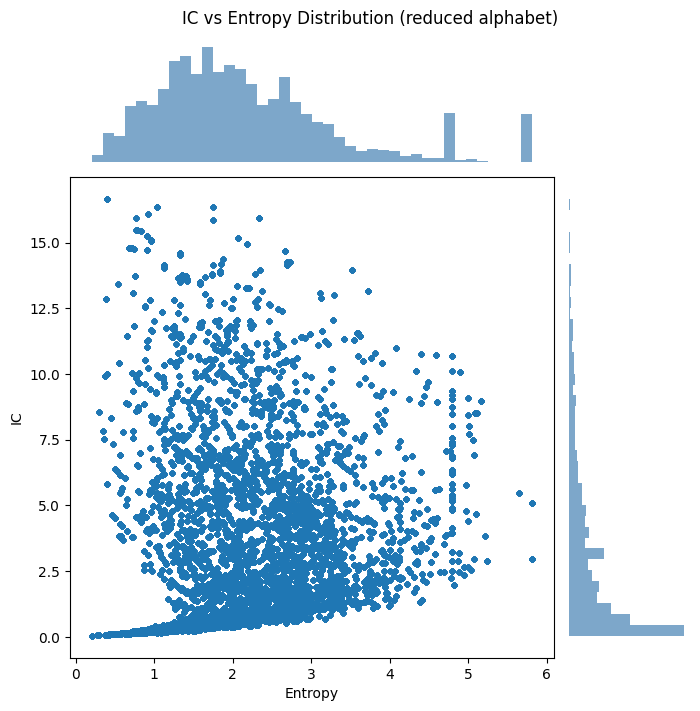

In [81]:
import matplotlib.pyplot as plt

seq_results_df = pd.read_csv("original_sequences_idyom.csv")

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(seq_results_df[COL_ENT], seq_results_df[COL_IC], alpha=0.4, s=10)
ax_main.set_xlabel("Entropy")
ax_main.set_ylabel("IC")

ax_top.hist(seq_results_df[COL_ENT], bins=40, color="steelblue", alpha=0.7)
ax_top.axis("off")

ax_right.hist(seq_results_df[COL_IC], bins=40, orientation="horizontal", color="steelblue", alpha=0.7)
ax_right.axis("off")

fig.suptitle("IC vs Entropy Distribution (reduced alphabet; 360 sequences)", y=0.92)
plt.show()

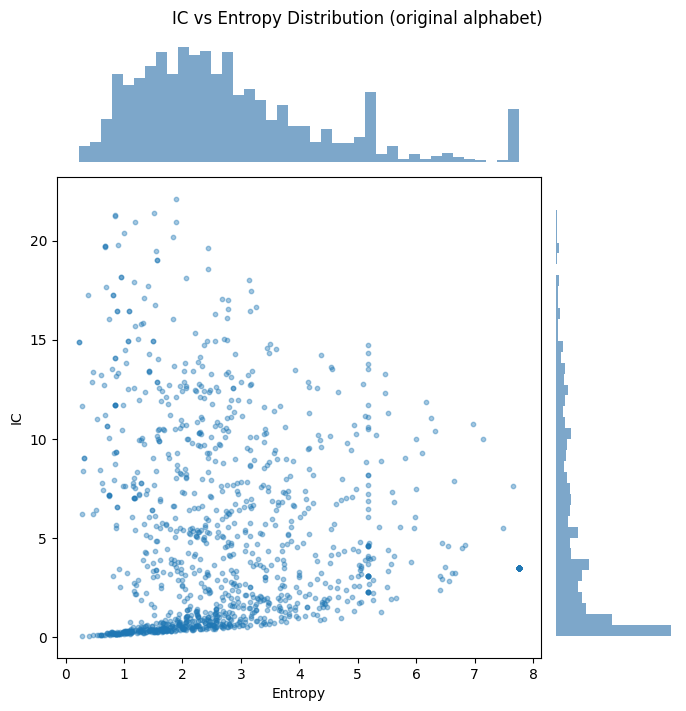

In [82]:
import matplotlib.pyplot as plt

seq_results_df = pd.read_csv("original_sequences_idyom_original_alphabet.csv")

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(seq_results_df[COL_ENT], seq_results_df[COL_IC], alpha=0.4, s=10)
ax_main.set_xlabel("Entropy")
ax_main.set_ylabel("IC")

ax_top.hist(seq_results_df[COL_ENT], bins=40, color="steelblue", alpha=0.7)
ax_top.axis("off")

ax_right.hist(seq_results_df[COL_IC], bins=40, orientation="horizontal", color="steelblue", alpha=0.7)
ax_right.axis("off")

fig.suptitle("IC vs Entropy Distribution (original alphabet; 32 sequences)", y=0.92)
plt.show()

# Test runs using IDyOMExperiment

In [26]:
from py2lisp.run import IDyOMExperiment

In [83]:
my_experiment = IDyOMExperiment(
    # LTM
    # pretrain_dataset_path='data/midi_train/',
    test_dataset_path='data/midi_test/'
)


my_experiment.set_parameters(target_viewpoints=['h-cpitch'], # basic harmony viewpoint predicted
                             source_viewpoints=['h-cpitch-class'], # 
                             models=':both',
                             k=':full',
                             texture=':harmony',
                             detail=3)

my_experiment.run()

** Putting Test dataset files in experiment history folder. **
** No pretraining dataset detected. **
** running lisp script **
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Inserting 1 compositions into database: dataset 66041026142410.
| Progress: -----------------------------------------------|
Written resampling set to /root/idyom/data/resampling/66041026142410-1.resample.
Written PPM* model to /root/idyom/data/models/h-cpitch-class_NIL_66041026142410-1:1_harmony.ppm.
 
** Finished! **


In [ ]:
my_experiment.set_parameters(target_viewpoints=['cpitch'],
                             source_viewpoints=['h-cpitch-class'],
                             models=':both',
                             k=':full',
                             texture=':melody',
                             detail=3)

my_experiment.run()

In [103]:
my_experiment = IDyOMExperiment(
    # pretrain_dataset_path='data/kern_train/',
    test_dataset_path='data/kern_train/',
    # test_dataset_path='data/txt_test/'
)

my_experiment.set_parameters(target_viewpoints=['cpitch'],
                             source_viewpoints=['cpitch'],
                             models=':both',
                             # k=':full',
                             # texture=':melody',
                             detail=3)

my_experiment.run()

** Putting Test dataset files in experiment history folder. **
** No pretraining dataset detected. **
** running lisp script **
Music file type unsupported. Please use either midi files or kern files.
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Type HELP for debugger help, or (SB-EXT:EXIT) to exit from SBCL.

restarts (invokable by number or by possibly-abbreviated name):
  0: [RETRY   ] Retry calling the generic function.
  1:            Retry EVAL of current toplevel form.
  2: [CONTINUE] Ignore error and continue loading file "/work/experiment_history/15-04-26_17.20.45/compute.lisp".
  3: [ABORT   ] Abort loading file "/work/experiment_history/15-04-26_17.20.45/compute.lisp".
  4:            Ignore runtime option --load "experiment_history/15-04-26_17.20.45/compute.lisp".
  5:            Skip rest of --eval and --load options.
  6:            Skip to toplevel READ/EVAL/PRINT lo

While evaluating the form starting at line 2, column 0
  of #P"/work/experiment_history/15-04-26_17.20.45/compute.lisp":

debugger invoked on a SB-PCL::NO-APPLICABLE-METHOD-ERROR in thread
#<THREAD "main thread" RUNNING {10024F0203}>:
  There is no applicable method for the generic function
    #<STANDARD-GENERIC-FUNCTION IDYOM-DB:IMPORT-DATA (6)>
  when called with arguments
    (:NONE
     "experiment_history/15-04-26_17.20.45/experiment_input_data_folder/test_dataset/"
     "TEST_DATASET" 66041526172045).
See also:
  The ANSI Standard, Section 7.6.6


In [23]:
import pandas as pd

output_path = 'experiment_history/08-04-26_17.45.54/experiment_output_data_folder/66040826174554-cpitch-cpitch-nil-nil-melody-nil-full-both-nil-t-nil-c-nil-t-t-x-3.dat'


df = pd.read_csv(output_path, delimiter='\s+', na_values='NA')

selected_cols = ['melody.id', 'melody.name', 'note.id', 'cpitch', 'ic', 'entropy', 'probability']
df.to_csv('idyom_all.csv', index=False)
df.to_csv('idyom.csv', columns=selected_cols, index=False)

df

,dataset.id,melody.id,note.id,melody.name,vertint12,articulation,comma,voice,ornament,dyn,...,cpitch.78,cpitch.79,cpitch.81,cpitch.83,cpitch.86,cpitch.88,probability,ic,entropy,information.gain
0,66040826174554,1,1,shanx001,NaN,NaN,NaN,1,NaN,NaN,...,0.078859,0.081053,0.091256,0.081053,0.071890,0.071890,0.081053,3.624987,3.696497,NaN
1,66040826174554,1,2,shanx001,NaN,NaN,NaN,1,NaN,NaN,...,0.048823,0.050245,0.056883,0.371897,0.044317,0.104183,0.371897,1.427027,3.169296,0.370481
2,66040826174554,1,3,shanx001,NaN,NaN,NaN,1,NaN,NaN,...,0.053751,0.054949,0.060440,0.324023,0.049901,0.096176,0.324023,1.625830,3.311873,0.009484
3,66040826174554,1,4,shanx001,NaN,NaN,NaN,1,NaN,NaN,...,0.030697,0.030969,0.032173,0.616137,0.029797,0.048977,0.616137,0.698678,2.330528,0.252912
4,66040826174554,1,5,shanx001,NaN,NaN,NaN,1,NaN,NaN,...,0.020571,0.020617,0.020816,0.751058,0.020416,0.023151,0.751058,0.413003,1.701825,0.067455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,66040826174554,3,28,shanx003,NaN,NaN,NaN,1,NaN,NaN,...,0.026066,0.218119,0.100752,0.030381,0.042461,0.022491,0.256517,1.962871,3.190886,2.308807
72,66040826174554,3,29,shanx003,NaN,NaN,NaN,1,NaN,NaN,...,0.013073,0.090675,0.058369,0.013985,0.029981,0.012252,0.449566,1.153396,2.696244,0.324006
73,66040826174554,3,30,shanx003,NaN,NaN,NaN,1,NaN,NaN,...,0.024670,0.124126,0.095803,0.028675,0.040634,0.021343,0.284271,1.814663,3.225214,0.119348
74,66040826174554,3,31,shanx003,NaN,NaN,NaN,1,NaN,NaN,...,0.025627,0.124591,0.098046,0.030053,0.040744,0.021983,0.264242,1.920067,3.258542,0.136836


In [84]:
# STM

my_experiment = IDyOMExperiment(
    # pretrain_dataset_path='data/kern_train/',
    test_dataset_path='data/kern_test/'
)

my_experiment.set_parameters(
    target_viewpoints=['cpitch'],
    source_viewpoints=['cpitch'],
    models=':stm',
    k=':full',
    texture=':melody',
    detail=3,
    # LTM params
    ltmo_order_bound=3,
    ltmo_update_exclusion=True,
    ltmo_escape=':c',
    ltmo_mixtures=False,
    # STM params
    stmo_order_bound=3,
    stmo_escape=':c',
    stmo_update_exclusion=True,
    stmo_mixtures=False,
)

my_experiment.run()



** Putting Test dataset files in experiment history folder. **
** No pretraining dataset detected. **
** running lisp script **
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Inserting 1 compositions into database: dataset 66041326022005.
| Progress: -----------------------------------------------|
** Finished! **


In [109]:
# update compute.lisp with this ID
# update compute.lisp with more self-defined arguments

my_experiment._generate_test_dataset_id()


'66041626001018'

In [113]:
import os
os.system("sbcl --dynamic-space-size 8192 --noinform --load experiment_history/15-04-26_17.20.45/compute.lisp")


To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
..............

Dataset 888888 deleted from the database.
Dataset 999999 deleted from the database.
Inserting 744 compositions into database: dataset 888888.
| Progress: -----------------------------------------------|
Inserting 51 compositions into database: dataset 999999.
| Progress: -----------------------------------------------|
Preserving existing output file: experiment_history/15-04-26_17.20.45/experiment_output_data_folder/999999-cpitch-cpitch-888888-nil-melody-nil-1-both-nil-t-nil-c-nil-t-t-x-3.dat


0

In [101]:
import pandas as pd

# exclusion = TRUE - matched with ppm
output_path = 'experiment_history/13-04-26_02.20.05/experiment_output_data_folder/66041326023201-cpitch-cpitch-nil-nil-melody-nil-full-stm-nil-t-nil-c-3-t-t-c-3.dat'
# exclusion = FALSE - not matched with ppm
# output_path = 'experiment_history/13-04-26_02.20.05/experiment_output_data_folder/66041326023457-cpitch-cpitch-nil-nil-melody-nil-full-stm-nil-t-nil-c-3-t-t-c-3.dat'

df = pd.read_csv(output_path, delimiter='\s+', na_values='NA')

selected_cols = ['melody.id', 'melody.name', 'note.id', 'cpitch', 'ic', 'entropy', 'probability']
df.to_csv('idyom_stm.csv', columns=selected_cols, index=False)

df

,dataset.id,melody.id,note.id,melody.name,vertint12,articulation,comma,voice,ornament,dyn,...,cpitch.probability,cpitch.ic,cpitch.entropy,cpitch.60,cpitch.69,cpitch.71,probability,ic,entropy,information.gain
0,66041326023201,1,1,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.333333,1.584963,1.584963,0.333333,0.333333,0.333333,0.333333,1.584963,1.584963,NaN
1,66041326023201,1,2,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.166667,2.584963,1.251629,0.166667,0.666667,0.166667,0.166667,2.584963,1.251629,0.333333
2,66041326023201,1,3,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.400000,1.321928,1.521928,0.200000,0.400000,0.400000,0.400000,1.321928,1.521928,0.236966
3,66041326023201,1,4,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.100000,3.321928,1.295462,0.100000,0.300000,0.600000,0.100000,3.321928,1.295462,0.132030
4,66041326023201,1,5,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.384615,1.378511,1.576621,0.307692,0.384615,0.307692,0.384615,1.378511,1.576621,0.308399
5,66041326023201,1,6,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.350000,1.514573,1.581291,0.350000,0.300000,0.350000,0.350000,1.514573,1.581291,0.023488
6,66041326023201,1,7,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.578947,0.788496,1.402993,0.210526,0.578947,0.210526,0.578947,0.788496,1.402993,0.228807
7,66041326023201,1,8,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.542857,0.881356,1.431006,0.542857,0.171429,0.285714,0.542857,0.881356,1.431006,0.636079
8,66041326023201,1,9,dummy,NaN,NaN,NaN,1,NaN,NaN,...,0.578947,0.788496,1.402993,0.210526,0.578947,0.210526,0.578947,0.788496,1.402993,0.566733
